
<div style="display: flex; align-items: center; justify-content: space-between;">

  <img src="../img/CTC_logo.png" style="height:60px;">

  <h2 style="margin: 0; text-align: center;">
    Hands-On: Developing predictive models for sustainable chemical systems
  </h2>

  <img src="../img/Universität_Leipzig_logo.png" style="height:90px;">

</div>


In this lecture block we will study how predictive models support the development of sustainable chemical systems.  Together we will:

* dive into the foundations of modelling
* develop data-driven models with hands-on examples
* apply the models for selecting solvents in line with green chemistry principles




In this lecture block we will directly move from theory to a practical problem:

* Lignin is a renewable resource that is commonly used as a material for creating lignin-based films, coatings and nanoparticles
* One step in this process is usuallly lignin dissolution
* 1,4-dioxane is the most commonly used solvent for that purpose due to its high lignin solubility
* However, dioxane is ......

* recap: principles of green chemistry

* Goal: we want to find a solvent that in the best case: outperforms dioxane in terms of lignin solubility, is less toxic, not explosive ....

* Show solvent selection guide
* we could go into the lab and test solvents from each class, still might not find agood one

* we could also use a model-based approach: test only the best remaining ones

* first step (today): Build the models and understand how they work. understand their limits and what they predict and what not
* second step: (next lecture)


In [34]:
import os
print(os.getcwd())

print(os.path.exists("../img/Universität_Leipzig_logo.png"))

/home/koenigmattern/Documents/Teaching/Sustainable_Chemical_Systems_UL/suschemsys
True


# Predictive Models for Sustainable Chemical Systems

## Recap: 12 principles of green chemistry

This lecture lays particular focus on how to facilitate lignin processing as a renewable resource using safer solvents compared to the benchmark 1,4-dioxane:

1. Waste prevention
2. Atom economy
3. Less Hazardous Chemical Syntheses
4. Designing Safer Chemicals
5. **Safer Solvents and Auxiliaries**
6. Design for Energy Efficiency
7. **Use of Renewable Feedstocks**
8. Reduce Derivatives
9. Catalysis
10. Design for Degradation
11. Real-time analysis for Pollution Prevention
12. Inherently Safer Chemistry for Accident Prevention


## Recap: lignin chemistry

!!!!!!!!!!!!!!!!!

## Toxicity

The dose makes the poison - Paracelsus

### Definitions

Depends on: 

* Dose / concentration
* Route of exposure (oral, inhalation, dermal)
* Duration (acute vs. chronic)
* Organism susceptibility (Human, rat, rabbit, mouse, algae, fish)

| Type | Description | Example |
|------|------------|---------|
| **Acute toxicity** | Effects from short-term exposure | Single high-dose poisoning |
| **Chronic toxicity** | Effects from long-term exposure | Carcinogenicity, liver damage |
| **Subacute / Subchronic toxicity** | Intermediate duration exposure | Repeated exposure for weeks/months |
| **Specific organ toxicity** | Targets specific organs | Hepatotoxicity (liver), nephrotoxicity (kidney) |
| **Developmental / reproductive toxicity** | Affects reproduction or fetal development | Teratogens |
| **Mutagenicity / Genotoxicity** | Alters DNA or causes mutations | Some chemicals cause cancer or DNA damage |


Note: For a holistic toxicity assessment, we would need to analyze all different forms of toxicity. Due to the limited time we have in the lecture, we need to focus on one type: **Acute toxicity**


### Acute toxicity: Globally Harmonised System (GHS) classification

| GHS Category | LD₅₀ (rat, oral) [mg/kg body weight] | Toxicity class name        | Signal word |
|--------------|--------------------------------------|----------------------------|-------------|
| Category 1   | ≤ 5                                  | Extremely toxic            | Danger      |
| Category 2   | > 5 – 50                             | Highly toxic               | Danger      |
| Category 3   | > 50 – 300                           | Toxic                      | Danger      |
| Category 4   | > 300 – 2,000                        | Harmful                    | Warning     |
| Category 5*  | > 2,000 – 5,000                      | May be harmful             | —           |
| Not classified | > 5,000                            | Practically non-toxic      | —           |

* Category 5 is optional under GHS and not always implemented in EU CLP.


## Planning the model

* Goal: find replacement for 1,4-dioxane
* Target properties: max lignin solubility, min toxicity

We need models that predict lignin solubility and toxicity

How accurate do they need to be?

Solubility: doesnt need to be accurate on a quantitative level. We just want to be able to rank the solvents. It's ok if the solubility predictions are off, as long as the relative ranking is fine

Toxicity: should be at least accurate enough to be within one toxicity class

Toxicity: Rat, Oral toxicity, LD50, paper. here we found a lot of data, and we develop the model together

Solubility: LKM paper -> here already have a model and we learn how it works

!!!!!!


## Select model type:

0. Select model type: Mechanistic vs black-box vs. **data-driven**
1. Data cleaning: retrieve high-quality data, check for duplets, outliers, if multiple descriptors: feature selection
2. Molecular embedding: The molecular structure must be made readable for the computer
3. Model training
4. Model testing
5. Evaluation
6. Analysis

https://github.com/darjacvetkovic/HSP-predictions/tree/main/data

## Import necessary packages

Python code starts with importing all packages that you require for your project

In [26]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display # For Jupyter notebooks
import ipdb
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## Toxicity modelling

### Getting the data


### Reading the data


### Preprocessing the data

#### Structural embeddings

How do we make structures readable for the machine? SMILES
Explain how smiles work and what they mean

What can we  do with the smiles?
canonicalized smiles: works like a unique identifier

detect duplicates


what alse can we do with the smile? we can read it into powerful cheminformatics toolboxes such as rdkit and open babel


what can these packages do? predict features, such as .....
predict fingerprints

explain fingerprints

build the model: Smiles -> fingerprints -> property

# Molecular embeddings

<center> <img src="../img/Embeddings_aspuru_guzik.png" alt="../img/Embeddings_aspuru_guzik.png" width="500"/> </center>

## SMILES

SMILES = Simplified Molecular Input Line Entry System

SMILES is a text-based language to represent chemical structures as a linear string, while encoding:

* atoms
* bonds
* branching
* ring closures
* stereochemistry
* charges and isotopes

Despite being one-dimensional text, SMILES encode structural information about the molecule. You can derive all 2D information, however, no 3D information, since positions of the atoms are not encoded.


### Atoms

| Atom type / feature        | SMILES notation | Example        | Meaning |
|----------------------------|-----------------|----------------|---------|
| Organic subset atom        | Element symbol  | `C`, `N`, `O`  | Common atoms, brackets not required |
| Aromatic atom              | lowercase       | `c`, `n`       | Aromatic atom |
| Bracketed atom             | `[X]`           | `[Fe]`         | Explicit atom with full specification |
| Charged atom               | `[X+]`, `[X-]`  | `[N+]`, `[O-]` | Formal charge |
| Explicit hydrogens         | `[XH]`, `[XHn]` | `[NH]`, `[NH4+]` | Explicit hydrogen count |
| Isotope specification     | `[nX]`          | `[13C]`        | Isotopically labeled atom |
| Chiral atom                | `@`, `@@`       | `[C@H](O)N`    | Tetrahedral stereochemistry |
| Wildcard atom              | `*`             | `*CC`          | Any atom (substructure queries) |
| Atom class (mapping)       | `:n`            | `[C:1]`        | Atom mapping / reaction SMILES |
| Dot-disconnect operator | `.`                | `[Na+].[Cl-]`  | For disconnections



### Bonds

| Bond type                     | SMILES symbol | Example        | Meaning |
|-------------------------------|---------------|----------------|---------|
| Single bond                   | `-` (optional) | `CC`           | C–C single bond |
| Double bond                   | `=`           | `C=C`          | C=C double bond |
| Triple bond                   | `#`           | `C#N`          | C≡N triple bond |
| Aromatic bond                 | `:`           | `c:c`          | Aromatic bond |
| Aromatic (implicit)           | *(none)*      | `c1ccccc1`     | Aromatic system |
| E/Z stereochemical bond       | `/`           | `F/C=C/F`      | Defines alkene geometry |
| E/Z stereochemical bond       | `\`           | `F/C=C\F`      | Defines alkene geometry |
| Tetrahedral chirality (bond direction) | `/` or `\` | `N[C@H](O)C` | Used with `@` to define chirality |


### Examples

| Molecule        | SMILES |
|-----------------|--------|
| Water           | `O` |
| Ethanol         | `CCO` |
| 2-Butanol       | `CC(C)CO` |
| Acetic acid     | `CC(=O)O` |
| L-Alanine       | `N[C@H](C)C(=O)O` |
| Glucose         | `OC[C@H]1O[C@@H](O)[C@H](O)[C@H](O)[C@H]1O` |

* hydrogen is encoded implicitly
* 2-butanol shows branching
* L-alanine explicitly encodes chirality with @
* glucose has many stereocenters, so SMILES becomes long quickly

### Strength and limitations

**Strength:**
* encode the 2D molecular graph, incl. atoms, bonds, branching, ring closures
* bonds: single, double, triple
* aromaticity: captured via lowercase letters
* captures formal charges, valence states and resonance (implicity)
* stereochemistry: E/Z isomerism, tetrahedral chirality (@, @@)
* also isotopic labelling possible
* salts, mixtures can be express via disconnector dot
* reactions with atom-mapping


**Limitations:**
* sensitivity to string order
* many representations for one structure
* no conformational information, we need to apply other techniques for that (e.g. UFF using RDKit)
* no conformer distributions, no Boltzmann weighting
* no partial charges
* orbital information
* spin states
* excited states
* different tautomers, different SMILES, example N-methylmethanimine: `C=NC`and `CN=C`
* no multi-center bonds, metal coordination, no agostic interactions, no π-complexes
* limited for polymers: can only mimic parts of polymers, no molecular weight distribution, degree of polymerization
* dot-disconnected SMILES: does not distinguaish between suspension, solution, salt, hydrogen-bonded complex etc.

Let's use SMILES to draw a molecue using RDKit:

Molecule without hydrogen:


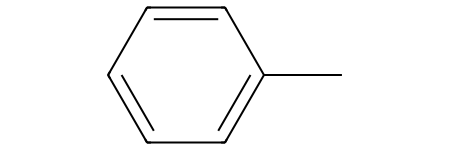

Molecule with hydrogen:


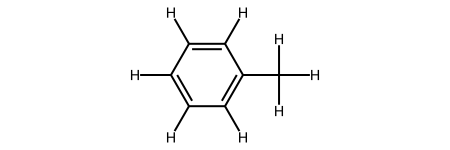

In [27]:
smi = "Cc1ccccc1" # Toluene         # define the SMILES, here: toluene
mol = Chem.MolFromSmiles(smi)       # get the RDKit mol obj from SMILES
mol_with_h = Chem.AddHs(mol)        # hydrogens are treated implicitly, so we wanna see them in the graphic, we need to add them

print('Molecule without hydrogen:')
display(mol)

print('Molecule with hydrogen:')
display(mol_with_h)

## Fingerprints

A molecular fingerprint is a vector that encodes the presence or absence of structural features in a molecule. Therefore, they describe molecules as fixed-length numerical embeddings that are readable for machines. These representations can be compared, searched and further processed, e.g for machine learning.


!!!!!!!!!!!!


Now we use our Toluene mol-object from RDKit that we generated using the SMILES and generate a fingerprint from that:

In [28]:
!!!!!!!!!!!!!!!!!

['/bin/bash: line 1: !!!!!!!!!!!!!!!: command not found']

## Building the Toxicity model

Now we wanna start modelling

!!!

val in mg substance per kg body weight

In [29]:
path_tox = "../code/data/toxicity_dataset.csv"
df = pd.read_csv(path_tox, sep=';')
print(df)

      Unnamed: 0                         SMILES     val
0              0                      Br/C=C\Br    62.0
1              1      BrC(Br)(Br)c1ccc2ccccc2n1  6769.0
2              2                      BrC(Br)Br   933.0
3              3                 BrC(Br)C(Br)Br  1200.0
4              4                    BrC/C=C/CBr    62.0
...          ...                            ...     ...
7296        7296               c1coc(OCC2CO2)c1  1100.0
7297        7297   c1nc(NC2CC2)c2ncn(C3CC3)c2n1   130.0
7298        7298  c1nc(NC2CC2)c2ncn(CC3CC3)c2n1   160.0
7299        7299                     c1nc[nH]n1  1648.0
7300        7300            c1nnc(NCNc2nncs2)s1   260.0

[7301 rows x 3 columns]


Now we wanna check for duplets

!!!!

First we need to canonicalize the smiles (make sure their all made the same way)


In our case, fingerprints will be the embedding of choice (not SMILES!). The SMILES are only used as a means to clean the dataset and to get the fingerprints.

In [30]:
def canonicalize(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None  # invalid SMILES

df['canonical_smiles'] = df['SMILES'].apply(canonicalize)   # apply the function "canonicalize" to the whole SMILES-column and put them into the new column "canocical_smiles"

print('Number of entries in the original dataset:')
print(df.shape[0])
print(df)

Number of entries in the original dataset:
7301
      Unnamed: 0                         SMILES     val  \
0              0                      Br/C=C\Br    62.0   
1              1      BrC(Br)(Br)c1ccc2ccccc2n1  6769.0   
2              2                      BrC(Br)Br   933.0   
3              3                 BrC(Br)C(Br)Br  1200.0   
4              4                    BrC/C=C/CBr    62.0   
...          ...                            ...     ...   
7296        7296               c1coc(OCC2CO2)c1  1100.0   
7297        7297   c1nc(NC2CC2)c2ncn(C3CC3)c2n1   130.0   
7298        7298  c1nc(NC2CC2)c2ncn(CC3CC3)c2n1   160.0   
7299        7299                     c1nc[nH]n1  1648.0   
7300        7300            c1nnc(NCNc2nncs2)s1   260.0   

                   canonical_smiles  
0                         Br/C=C\Br  
1         BrC(Br)(Br)c1ccc2ccccc2n1  
2                         BrC(Br)Br  
3                    BrC(Br)C(Br)Br  
4                       BrC/C=C/CBr  
...            

[21:14:26] Explicit valence for atom # 1 Si, 4, is greater than permitted
[21:14:26] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


First, let's check for missing values. Is there any structure without value?

In [31]:
print(df.isnull().sum())

Unnamed: 0          0
SMILES              0
val                 0
canonical_smiles    1
dtype: int64


Looks good!

then check for double or multiple entries

In [32]:
df_unique = df.drop_duplicates(subset='canonical_smiles')   # drop multiple entries

print('Number of entries after erasing duplicates:')
print(df.shape[0])

Number of entries after erasing duplicates:
7301


Same number as before! That means, our dataset did not contain duplets, nice!

After the initial analysis, let's inspect our data a bit deeper. Since the model learns from data, the model can only describe well what is has seen. What's the limits in terms of structural and value ranges? Let's have a look at the LD_{50} values. Lets make a histogram plot of how many extremely toxic and less toxic substances we have 

!!!!!



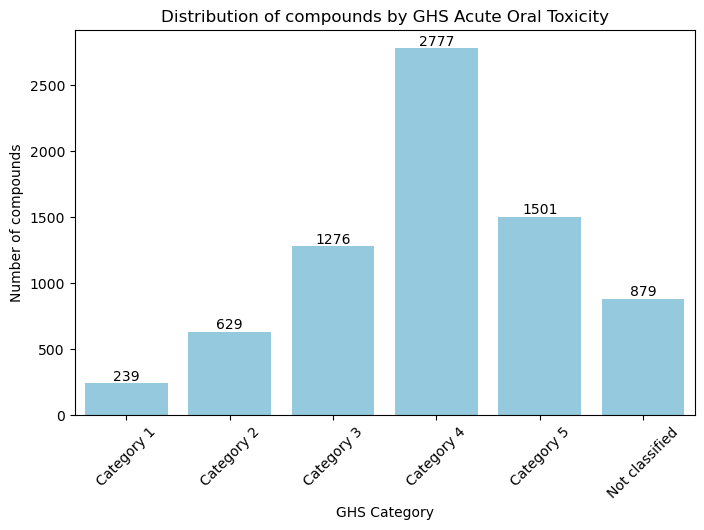

In [33]:
def ghs_category(val):
    if val <= 5:
        return "Category 1"
    elif val <= 50:
        return "Category 2"
    elif val <= 300:
        return "Category 3"
    elif val <= 2000:
        return "Category 4"
    elif val <= 5000:
        return "Category 5"
    else:
        return "Not classified"


df['GHS_category'] = df['val'].apply(ghs_category)                         # Add a cloumn with the GHS category

category_counts = df['GHS_category'].value_counts().sort_index()            # Count the entries per category

# Now let's plot!


plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GHS_category', order=[
    "Category 1","Category 2","Category 3","Category 4","Category 5","Not classified"],
    color="skyblue", 
)
plt.xlabel("GHS Category")
plt.ylabel("Number of compounds")
plt.title("Distribution of compounds by GHS Acute Oral Toxicity")
plt.xticks(rotation=45)

# Show counts on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(int(p.get_height()), (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom')

plt.show()

That was easy! Now we need to also analyze the structural diversity.

!!!!